In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import ticker
from plot import plot_image, make_theme, turbo_w, plot_label, format_cbar
folder='calc_Ba3CeIr2O9'
%matplotlib inline
plt.rcParams['font.size'] = 7

import warnings
warnings.filterwarnings('ignore')

# Figure 2

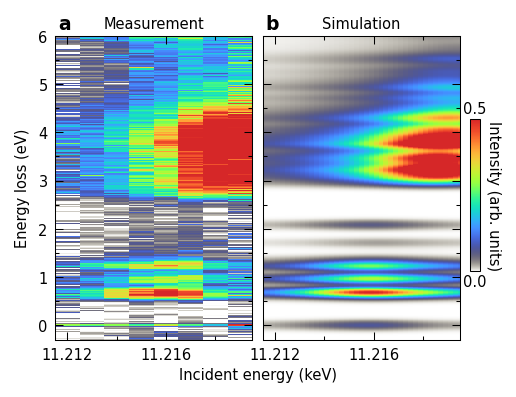

In [2]:
Emap_data = dict(eloss=None, omega=[], intensity=[])

f = h5py.File('data/Ce_data_energyMap.hdf5', 'r')
scan = dict()
for scan_no in f:
    for dset_name in f[scan_no]:
        scan[dset_name] = np.array(f[scan_no][dset_name])
    if Emap_data['eloss'] is None:
        Emap_data['eloss'] = scan['x']
    Emap_data['omega'].append(scan['Ei'])
    bg = np.mean(scan['y'][np.logical_and(scan['x']>=250., scan['x']<=350.)])
    Emap_data['intensity'].append(np.interp(Emap_data['eloss'], scan['x']-scan['xoffset'], (scan['y']-bg)/scan['ab_factor']))
Emap_data['intensity'] = np.vstack(Emap_data['intensity']).T
f.close()

f = h5py.File('data/Ce_calc_energyMap.hdf5', 'r')
Emap_calc = dict()
for dset_name in f['energyMap']:
    Emap_calc[dset_name] = np.array(f['energyMap'][dset_name])
f.close()

fig = plt.figure(figsize=(6.75/2,6.75/2/4*3), dpi=150)
gs1 = fig.add_gridspec(nrows=1, ncols=1, left=0.10, right=0.49, top=0.92, bottom=0.12) # Emap1
gs2 = fig.add_gridspec(nrows=1, ncols=1, left=0.51, right=0.90, top=0.92, bottom=0.12) # Emap2
gs3 = fig.add_gridspec(nrows=1, ncols=1, left=0.92, right=0.94, top=0.70, bottom=0.30) # colorbar
axs  = [fig.add_subplot(gs) for gs in gs1] + [fig.add_subplot(gs) for gs in gs2] # Emaps
axs += [fig.add_subplot(gs) for gs in gs3] # colorbar

## plot
_, art = plot_image(Emap_data['intensity'], x=Emap_data['omega'], y=Emap_data['eloss']/1e3,
           ax=axs[0], cmap=turbo_w(), vmin=0., vmax=0.5)
_, art = plot_image(Emap_calc['rixs'].T, x=Emap_calc['omega'], y=Emap_calc['eloss'],
           ax=axs[1], cmap=turbo_w(), vmin=0., vmax=0.5)
## colorbar
cbar = plt.colorbar(art, ax=axs[1], cax=axs[2])
format_cbar(cbar, padding=0.07)
## format
axs[1].set_xlim(axs[0].get_xlim())
for ax in axs[:2]:
    make_theme(ax, ticklength=4)
    ax.set_ylim(-0.3,6)
    ax.set_yticks(np.arange(0.,6.1,1.))
    ax.set_xticks(np.arange(11.212,11.2191,0.004))
axs[1].tick_params(labelleft=False)
axs[0].set_xlabel('Incident energy (keV)')
axs[0].xaxis.set_label_coords(1.028, -.09)
axs[0].set_ylabel('Energy loss (eV)')
plot_label(axs[0], 'a', x=0.05, y=1.04, color='k')
axs[0].text(0.5, 1.04, 'Measurement', color='k', transform=axs[0].transAxes,
            horizontalalignment='center', verticalalignment='center')
plot_label(axs[1], 'b', x=0.05, y=1.04, color='k')
axs[1].text(0.5, 1.04, 'Simulation', color='k', transform=axs[1].transAxes,
            horizontalalignment='center', verticalalignment='center')
plt.show()

# Figure 3

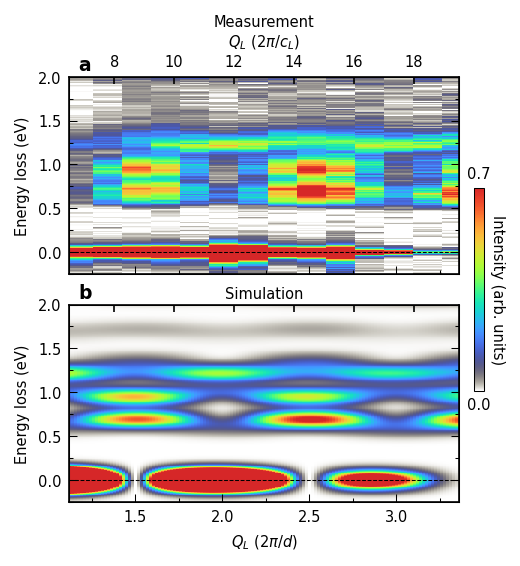

In [3]:
d = 2.53614
factor = 0.426991866 * d / (2*np.pi)
Qmap_data = dict(eloss=None, HKL=[], intensity=[])

f = h5py.File('data/Ce_data_qMap.hdf5', 'r')
scan = dict()
for scan_no in f:
    for dset_name in f[scan_no]:
        scan[dset_name] = np.array(f[scan_no][dset_name])
    if Qmap_data['eloss'] is None:
        Qmap_data['eloss'] = scan['x']
    Qmap_data['HKL'].append(scan['HKL'])
    bg = np.mean(scan['y'][np.logical_and(scan['x']>=250., scan['x']<=350.)])
    Qmap_data['intensity'].append(np.interp(Qmap_data['eloss'], scan['x']-scan['xoffset'], (scan['y']-bg)/scan['ab_factor']))
Qmap_data['intensity'] = np.vstack(Qmap_data['intensity']).T
Qmap_data['HKL'] = np.vstack(Qmap_data['HKL'])
f.close()

f = h5py.File('data/Ce_calc_qMap.hdf5', 'r')
Qmap_calc = dict()
for dset_name in f['qMap']:
    Qmap_calc[dset_name] = np.array(f['qMap'][dset_name])
f.close()

fig = plt.figure(figsize=(6.75/2,6.75/2), dpi=150)
gs1 = fig.add_gridspec(nrows=1, ncols=1, left=0.12, right=0.89, top=0.94, bottom=0.55) # Qmap1
gs2 = fig.add_gridspec(nrows=1, ncols=1, left=0.12, right=0.89, top=0.49, bottom=0.10) # Qmap2
gs3 = fig.add_gridspec(nrows=1, ncols=1, left=0.92, right=0.94, top=0.72, bottom=0.32)  # colorbar
axs =  [fig.add_subplot(gs) for gs in gs1] + [fig.add_subplot(gs) for gs in gs2] # Qmaps
axs += [fig.add_subplot(gs) for gs in gs3] # colorbar

#plot
_, art = plot_image(Qmap_data['intensity'], x=Qmap_data['HKL'][:,2]*factor, y=Qmap_data['eloss']/1e3,
                    ax=axs[0], cmap=turbo_w(), vmin=0., vmax=0.7)
choose = Qmap_calc['eloss']<=2.1
_, art = plot_image(Qmap_calc['rixs'].T[choose,:], x=Qmap_calc['Ls']*factor, y=Qmap_calc['eloss'][choose],
                    ax=axs[1], cmap=turbo_w(), vmin=0., vmax=0.7)
## colorbar
cbar = plt.colorbar(art, ax=axs[1], cax=axs[2])
format_cbar(cbar, padding=0.07)
## format
for ax in axs[:2]:
    make_theme(ax, ticklength=4)
    ax.axhline(y=0., ls='--', lw=0.5, color='k', zorder=100)
    ax.set_ylim(-0.25,2)
    ax.set_yticks(np.arange(0.,2.1,0.5))
    ax.set_xlim(1.12,3.36)
    ax.set_xticks(np.arange(1.5,3.5,0.5))
    ax.set_ylabel('Energy loss (eV)')
axs[0].tick_params(labelbottom=False)
axs[1].set_xlabel('$Q_L$ ($2\pi/d$)')
plot_label(axs[0], 'a', x=0.04, y=1.06, color='k')
axs[0].set_title('Measurement', fontsize=7, pad=3)
plot_label(axs[1], 'b', x=0.04, y=1.06, color='k')
axs[1].set_title('Simulation', fontsize=7, pad=3)
axs_top = axs[0].twiny()
axs_top.set_xlim(1.12/factor,3.36/factor)
axs_top.set_xlabel('$Q_L$ ($2\pi/c_L$)')
axs_top.tick_params(direction='in')
axs_top = axs[1].twiny()
axs_top.set_xlim(1.12/factor,3.36/factor)
axs_top.tick_params(labeltop=False,direction='in')
plt.show()

# Figure 4

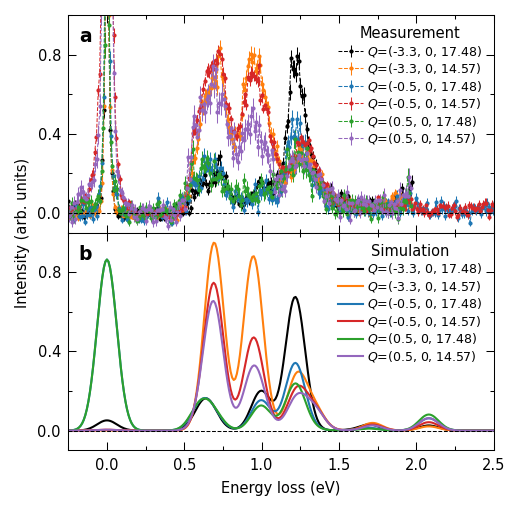

In [4]:
Cmap_data = []
f = h5py.File('data/Ce_data_cutMap.hdf5', 'r')
scan = dict()
for scan_no in f:
    for dset_name in f[scan_no]:
        scan[dset_name] = np.array(f[scan_no][dset_name])
    bg = np.mean(scan['y'][np.logical_and(scan['x']>=250., scan['x']<=350.)])
    Cmap_data.append(dict(x=(scan['x']-scan['xoffset'])/1e3, y=(scan['y']-bg)/scan['ab_factor'], 
                         yerr=scan['yerr']/scan['ab_factor'], HKLc=[scan['HKL'][0], scan['HKL'][1], scan['HKL'][2], scan['qc']]))
f.close()

Cmap_calc = []
f = h5py.File('data/Ce_calc_cutMap.hdf5', 'r')
Cmap_calc.append(dict(x=np.array(f['0']['eloss']), y=np.array(f['0']['rixs']), Q='(-3.3, 0, 17.48)', qc=6))
Cmap_calc.append(dict(x=np.array(f['1']['eloss']), y=np.array(f['1']['rixs']), Q='(-3.3, 0, 14.57)', qc=5))
Cmap_calc.append(dict(x=np.array(f['2']['eloss']), y=np.array(f['2']['rixs']), Q='(-0.5, 0, 17.48)', qc=6))
Cmap_calc.append(dict(x=np.array(f['3']['eloss']), y=np.array(f['3']['rixs']), Q='(-0.5, 0, 14.57)', qc=5))
Cmap_calc.append(dict(x=np.array(f['4']['eloss']), y=np.array(f['4']['rixs']), Q='(0.5, 0, 17.48)', qc=6))
Cmap_calc.append(dict(x=np.array(f['5']['eloss']), y=np.array(f['5']['rixs']), Q='(0.5, 0, 14.57)', qc=5))
f.close()


fig, axs = plt.subplots(2, 1, sharex=True, sharey=True, figsize=(6.75/2,6.75/2), dpi=150,
                        gridspec_kw=dict(left=0.12, right=0.96, bottom=0.10, top=0.96, hspace=0.))

## plot
for scan1, scan2, color in zip(Cmap_data, Cmap_calc, ['k','C1','C0','C3','C2','C4']):
    choose = scan1['x']<=2.6
    axs[0].errorbar(scan1['x'][choose], scan1['y'][choose], scan1['yerr'][choose], fmt='o', color=color, ls='--', lw=0.5, ms=1,
                    label='$Q$=({:.1f}, {:.0f}, {:.2f})'.format(scan1['HKLc'][0], abs(scan1['HKLc'][1]), scan1['HKLc'][2]))
    choose = scan2['x']<=2.6
    axs[1].plot(scan2['x'][choose], scan2['y'][choose], '-', lw=1, color=color, label='$Q$='+scan2['Q'])
## format
axs[0].legend(loc='upper right', frameon=False, handletextpad=0.3, labelspacing=0.2, fontsize=6, title='Measurement')
axs[1].legend(loc='upper right', frameon=False, handletextpad=0.3, labelspacing=0.2, fontsize=6, title='Simulation')
for ax in axs:
    make_theme(ax, ticklength=4)
    ax.axhline(y=0., ls='--', lw=0.5, color='k', zorder=100)
axs[0].set_xlim(-0.25, 2.5)
axs[0].set_xticks(np.arange(0.,2.51,0.5))
axs[0].set_ylim(-0.1,1)
axs[0].set_yticks(np.arange(0.,1.01,0.4))
axs[1].set_xlabel('Energy loss (eV)')
axs[0].set_ylabel('Intensity (arb. units)')
axs[0].yaxis.set_label_coords(-0.09,0.)
plot_label(axs[0], 'a', x=0.04, y=0.9, color='k')
plot_label(axs[1], 'b', x=0.04, y=0.9, color='k')
plt.show()

# Figure 5

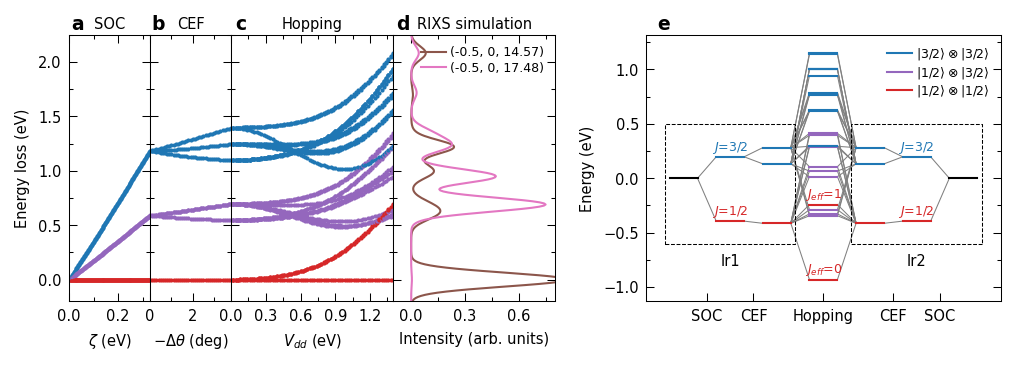

In [5]:
def plot_SOC(ax):
    dth = 0.
    Vdd = 0.
    f = h5py.File('data/evals_soc.hdf5', 'r')
    for soc in np.arange(0.002,0.331,0.002):
        evals = np.array(f['soc_{:.3f}_dth_{:.2f}_Vdd_{:.2f}'.format(soc, dth, Vdd)]['evals'])[:36]
        evals = np.round(evals, 6)
        evals = evals - np.min(evals)
        ax.plot(soc, np.mean(evals[:4]), 'o', ms=1, color='C3')
        ax.plot(soc, np.mean(evals[4:20]), 'o', ms=1, color='C4')
        ax.plot(soc, np.mean(evals[20:36]), 'o', ms=1, color='C0')
    f.close()
    format
    make_theme(ax, ticklength=4)
    ax.set_title('SOC', fontsize=7, pad=3)
    ax.set_xlabel('$\\zeta$ (eV)')
    ax.set_xlim(0,0.33)
    ax.set_xticks(np.arange(0.,0.331,0.2))
    ax.set_ylabel('Energy loss (eV)')
    ax.set_ylim(-0.2,2.25)
    ax.set_yticks(np.arange(0.,2.1,0.5))

def plot_CEF(ax):
    soc = 0.33
    Vdd = 0.
    f = h5py.File('data/evals_dth.hdf5', 'r')
    for dth in np.arange(-0.001,3.801,0.1):
        evals = np.array(f['soc_{:.3f}_dth_{:.2f}_Vdd_{:.2f}'.format(soc, -dth, Vdd)]['evals'])[:36]
        evals = np.round(evals, 6)
        evals = evals - np.min(evals)
        energies = np.unique(evals)
        ax.plot(dth, energies[0], 'o', ms=1, color='C3')
        for energy in energies[1:]:
            if energy<=1.:
                ax.plot(dth, np.mean(energy), 'o', ms=1, color='C4')
            else:
                ax.plot(dth, np.mean(energy), 'o', ms=1, color='C0')
    f.close()
    format
    make_theme(ax, ticklength=4)
    ax.tick_params(labelleft=False)
    ax.set_title('CEF', fontsize=7, pad=3)
    ax.set_xlabel('$-\\Delta\\theta$ (deg)')
    ax.set_xlim(0,3.8)
    ax.set_xticks(np.arange(0.,3.801,2.))
    ax.set_ylim(-0.2,2.25)
    ax.set_yticks(np.arange(0.,2.1,0.5))

def plot_hopping(ax):
    soc = 0.33
    dth = 3.8
    f = h5py.File('data/evals_Vdd.hdf5', 'r')
    for Vdd in np.arange(0.,1.151,0.02):
        evals = np.array(f['soc_{:.3f}_dth_{:.2f}_Vdd_{:.2f}'.format(soc, -dth, Vdd)]['evals'])[:36]
        evals = np.round(evals, 6)
        evals = evals - np.min(evals)
        for energy in np.unique(evals[:4]):
            ax.plot(Vdd, energy, 'o', ms=1, color='C3')
        for energy in np.unique(evals[4:20]):
            ax.plot(Vdd, energy, 'o', ms=1, color='C4')
        for energy in np.unique(evals[20:]):
            ax.plot(Vdd, energy, 'o', ms=1, color='C0')
    for Vdd in np.arange(1.16,1.261,0.02):
        evals = np.array(f['soc_{:.3f}_dth_{:.2f}_Vdd_{:.2f}'.format(soc, -dth, Vdd)]['evals'])[:36]
        evals = np.round(evals, 6)
        evals = evals - np.min(evals)
        for energy in np.unique(evals[:4]):
            ax.plot(Vdd, energy, 'o', ms=1, color='C3')
        for energy in np.unique(evals[4:17]):
            ax.plot(Vdd, energy, 'o', ms=1, color='C4')
        for energy in np.unique(evals[18:21]):
            ax.plot(Vdd, energy, 'o', ms=1, color='C4')
        ax.plot(Vdd, evals[17], 'o', ms=1, color='C0')
        for energy in np.unique(evals[21:]):
            ax.plot(Vdd, energy, 'o', ms=1, color='C0')
    for Vdd in np.arange(1.28,1.361,0.02):
        evals = np.array(f['soc_{:.3f}_dth_{:.2f}_Vdd_{:.2f}'.format(soc, -dth, Vdd)]['evals'])[:36]
        evals = np.round(evals, 6)
        evals = evals - np.min(evals)
        ax.plot(Vdd, evals[0], 'o', ms=1, color='C3')
        for energy in np.unique(evals[8:17]):
            ax.plot(Vdd, energy, 'o', ms=1, color='C4')
        for energy in np.unique(evals[18:21]):
            ax.plot(Vdd, energy, 'o', ms=1, color='C4')
        ax.plot(Vdd, evals[17], 'o', ms=1, color='C0')
        for energy in np.unique(evals[21:]):
            ax.plot(Vdd, energy, 'o', ms=1, color='C0')
    for Vdd in np.arange(1.38,1.401,0.02):
        evals = np.array(f['soc_{:.3f}_dth_{:.2f}_Vdd_{:.2f}'.format(soc, -dth, Vdd)]['evals'])[:36]
        evals = np.round(evals, 6)
        evals = evals - np.min(evals)
        ax.plot(Vdd, evals[0], 'o', ms=1, color='C3')
        for energy in np.unique(evals[5:8]):
            ax.plot(Vdd, energy, 'o', ms=1, color='C3')
        for energy in np.unique(evals[1:5]):
            ax.plot(Vdd, energy, 'o', ms=1, color='C4')
        for energy in np.unique(evals[8:15]):
            ax.plot(Vdd, energy, 'o', ms=1, color='C4')
        for energy in np.unique(evals[16:21]):
            ax.plot(Vdd, energy, 'o', ms=1, color='C4')
        ax.plot(Vdd, evals[15], 'o', ms=1, color='C0')
        for energy in np.unique(evals[21:]):
            ax.plot(Vdd, energy, 'o', ms=1, color='C0')
    Vdd = 1.28
    evals = np.array(f['soc_{:.3f}_dth_{:.2f}_Vdd_{:.2f}'.format(soc, -dth, Vdd)]['evals'])[:36]
    evals = np.round(evals, 6)
    evals = evals - np.min(evals)
    ax.plot(Vdd, evals[1], 'o', ms=1, color='C4')
    ax.plot(Vdd, evals[3], 'o', ms=1, color='C4')
    ax.plot(Vdd, np.mean(evals[6:8]), 'o', ms=1, color='C4')
    ax.plot(Vdd, evals[2], 'o', ms=1, color='C3')
    ax.plot(Vdd, np.mean(evals[4:6]), 'o', ms=1, color='C3')
    for Vdd in [1.3,1.32]:
        evals = np.array(f['soc_{:.3f}_dth_{:.2f}_Vdd_{:.2f}'.format(soc, -dth, Vdd)]['evals'])[:36]
        evals = np.round(evals, 6)
        evals = evals - np.min(evals)
        ax.plot(Vdd, evals[1], 'o', ms=1, color='C4')
        ax.plot(Vdd, evals[2], 'o', ms=1, color='C4')
        ax.plot(Vdd, np.mean(evals[6:8]), 'o', ms=1, color='C4')
        ax.plot(Vdd, evals[3], 'o', ms=1, color='C3')
        ax.plot(Vdd, np.mean(evals[4:6]), 'o', ms=1, color='C3')
    Vdd = 1.34
    evals = np.array(f['soc_{:.3f}_dth_{:.2f}_Vdd_{:.2f}'.format(soc, -dth, Vdd)]['evals'])[:36]
    evals = np.round(evals, 6)
    evals = evals - np.min(evals)
    ax.plot(Vdd, evals[1], 'o', ms=1, color='C4')
    ax.plot(Vdd, evals[2], 'o', ms=1, color='C4')
    ax.plot(Vdd, np.mean(evals[4:6]), 'o', ms=1, color='C4')
    ax.plot(Vdd, evals[3], 'o', ms=1, color='C3')
    ax.plot(Vdd, np.mean(evals[6:8]), 'o', ms=1, color='C3')
    Vdd = 1.36
    evals = np.array(f['soc_{:.3f}_dth_{:.2f}_Vdd_{:.2f}'.format(soc, -dth, Vdd)]['evals'])[:36]
    evals = np.round(evals, 6)
    evals = evals - np.min(evals)
    ax.plot(Vdd, evals[1], 'o', ms=1, color='C4')
    ax.plot(Vdd, evals[2], 'o', ms=1, color='C4')
    ax.plot(Vdd, np.mean(evals[3:5]), 'o', ms=1, color='C4')
    ax.plot(Vdd, evals[5], 'o', ms=1, color='C3')
    ax.plot(Vdd, np.mean(evals[6:8]), 'o', ms=1, color='C3')
    f.close()
    format
    make_theme(ax, ticklength=4)
    ax.tick_params(labelleft=False)
    ax.set_title('Hopping', fontsize=7, pad=3)
    ax.set_xlabel('$V_{dd}$ (eV)')
    ax.set_xlim(0.,1.4)
    ax.set_xticks(np.arange(0.,1.401,0.3))
    ax.set_ylim(-0.2,2.25)
    ax.set_yticks(np.arange(0.,2.1,0.5))

def plot_RIXS(ax):
    f = h5py.File('data/Ce_calc_cutMap.hdf5', 'r')
    rixs4 = np.array(f['4']['rixs'])
    rixs3 = np.array(f['3']['rixs'])
    eloss = np.array(f['4']['eloss'])
    f.close()
    choose = np.logical_and(eloss>=-0.5, eloss<=2.25)
    ax.plot(rixs4[choose], eloss[choose], '-', lw=1, color='C5', label='(-0.5, 0, 14.57)')
    ax.plot(rixs3[choose], eloss[choose], '-', lw=1, color='C6', label='(-0.5, 0, 17.48)')
    format
    make_theme(ax, ticklength=4)
    ax.tick_params(labelleft=False)
    ax.set_title('RIXS simulation', fontsize=7, pad=3)
    ax.set_xlabel('Intensity (arb. units)')
    ax.set_xlim(-0.1,0.8)
    ax.set_xticks(np.arange(0.,0.801,0.3))
    ax.legend(loc='upper right', frameon=False, handletextpad=0.3, labelspacing=0.2, fontsize=6)
    ax.set_ylim(-0.2,2.25)
    ax.set_yticks(np.arange(0.,2.1,0.5))
    
def plot_level(ax):
    lw = 1
    dash_params = dict(ls='-', color='gray', zorder=-1, lw=0.5)
    # plot
    ax.plot([-16.5,-13.5], [0.,0.], '-', lw=lw, color='k')
    ax.plot([13.5, 16.5], [0.,0.], '-', lw=lw, color='k')
    # SOC
    f = h5py.File('data/evals_soc.hdf5', 'r')
    evals = np.array(f['soc_{:.3f}_dth_{:.2f}_Vdd_{:.2f}'.format(0.33,0.,0.)]['evals'])
    evals = np.round(evals, 6)
    f.close()
    energy1A = np.mean(evals[:4])/2 # J=1/2 energy
    energy1B = np.mean(evals[4:20]) - energy1A # J=3/2 energy
    energy1C = np.mean(evals[20:36])/2 # J=3/2 energy, should be same as energy 1B
    GS = (energy1A*2 + energy1B*4) / 6
    energy1A = energy1A - GS
    energy1B = energy1B - GS
    ax.plot([-11.5,-8.5],  [energy1A,energy1A], '-', lw=lw, color='C3')
    ax.plot([11.5,8.5],  [energy1A,energy1A], '-', lw=lw, color='C3')
    ax.plot([-13.5,-11.5], [0.,energy1A], **dash_params)
    ax.plot([13.5,11.5], [0.,energy1A], **dash_params)
    ax.text(-10, energy1A+0.06, '$J$=1/2', color='C3', horizontalalignment='center', fontsize=6)
    ax.text(10, energy1A+0.06, '$J$=1/2', color='C3', horizontalalignment='center', fontsize=6)
    ax.plot([-11.5,-8.5],  [energy1B,energy1B], '-', lw=lw, color='C0')
    ax.plot([11.5,8.5],  [energy1B,energy1B], '-', lw=lw, color='C0')
    ax.plot([-13.5,-11.5], [0.,energy1B], **dash_params)
    ax.plot([13.5,11.5], [0.,energy1B], **dash_params)
    ax.text(-10, energy1B+0.06, '$J$=3/2', color='C0', horizontalalignment='center', fontsize=6)
    ax.text(10, energy1B+0.06, '$J$=3/2', color='C0', horizontalalignment='center', fontsize=6)
    ## CEF
    f = h5py.File('data/evals_dth.hdf5', 'r')
    evals = np.array(f['soc_{:.3f}_dth_{:.2f}_Vdd_{:.2f}'.format(0.33,-3.8,0.)]['evals'])
    evals = np.round(evals, 6)
    f.close()
    energy2A = np.mean(evals[:4])/2 # J=1/2 energy
    energy2B = np.mean(evals[4:12]) - energy2A # J=1/2 energy
    energy2C = np.mean(evals[12:20]) - energy2A # J=1/2 energy
    GS = np.mean([energy2A, energy2B, energy2C])
    energy2A = energy2A - GS
    energy2B = energy2B - GS
    energy2C = energy2C - GS
    ax.plot([-6.5,-3.5], [energy2A,energy2A], '-', lw=lw, color='C3')
    ax.plot([6.5,3.5],   [energy2A,energy2A], '-', lw=lw, color='C3')
    ax.plot([-8.5,-6.5], [energy1A,energy2A], **dash_params)
    ax.plot([8.5,6.5], [energy1A,energy2A], **dash_params)
    ax.plot([-6.5,-3.5], [energy2B,energy2B], '-', lw=lw, color='C0')
    ax.plot([6.5,3.5],   [energy2B,energy2B], '-', lw=lw, color='C0')
    ax.plot([-8.5,-6.5], [energy1B,energy2B], **dash_params)
    ax.plot([8.5,6.5], [energy1B,energy2B], **dash_params)
    ax.plot([-6.5,-3.5], [energy2C,energy2C], '-', lw=lw, color='C0')
    ax.plot([6.5,3.5],   [energy2C,energy2C], '-', lw=lw, color='C0')
    ax.plot([-8.5,-6.5], [energy1B,energy2C], **dash_params)
    ax.plot([8.5,6.5], [energy1B,energy2C], **dash_params)
    # Hopping
    f = h5py.File('data/evals_Vdd.hdf5', 'r')
    evals = np.array(f['soc_{:.3f}_dth_{:.2f}_Vdd_{:.2f}'.format(0.33,-3.8,1.4)]['evals'])
    evals = np.round(evals, 6)
    f.close()
    GS = (evals[0] + np.mean(evals[5:8])*3) / 4 - energy2A
    evals = evals - GS
    energy3A = np.mean(evals[:1])
    ax.plot([-1.5,1.5], [energy3A,energy3A], '-', lw=lw, color='C3')
    ax.plot([-3.5,-1.5], [energy2A,energy3A], **dash_params)
    ax.plot([3.5,1.5],   [energy2A,energy3A], **dash_params)
    ax.text(0, energy3A+0.06, '$J_{eff}$=0', color='C3', horizontalalignment='center', fontsize=6)
    energy3B = np.mean(evals[5:8])
    ax.plot([-1.5,1.5], [energy3B,energy3B], '-', lw=lw, color='C3')
    ax.plot([-3.5,-1.5], [energy2A,energy3B], **dash_params)
    ax.plot([3.5,1.5],   [energy2A,energy3B], **dash_params)
    ax.text(0, energy3B+0.06, '$J_{eff}$=1', color='C3', horizontalalignment='center', fontsize=6)
    evals_tmp = np.hstack([evals[8:12], evals[13:15], evals[16:18]])
    energies = np.unique(evals_tmp)
    for energy in energies:
        ax.plot([-1.5,1.5], [energy,energy], '-', lw=lw, color='C4')
        ax.plot([-3.5,-1.5], [energy2A,energy], **dash_params)
        ax.plot([-3.5,-1.5], [energy2B,energy], **dash_params)
        ax.plot([3.5,1.5],   [energy2A,energy], **dash_params)
        ax.plot([3.5,1.5],   [energy2B,energy], **dash_params)
    evals_tmp = np.hstack([evals[1:5], evals[12], evals[18:21]])
    energies = np.unique(evals_tmp)
    for energy in energies:
        ax.plot([-1.5,1.5],  [energy,energy], '-', lw=lw, color='C4')
        ax.plot([-3.5,-1.5], [energy2A,energy], **dash_params)
        ax.plot([-3.5,-1.5], [energy2C,energy], **dash_params)
        ax.plot([3.5,1.5],   [energy2A,energy], **dash_params)
        ax.plot([3.5,1.5],   [energy2C,energy], **dash_params)
    evals_tmp = evals[29:33]
    energies = np.unique(evals_tmp)
    for energy in energies:
        ax.plot([-1.5,1.5],  [energy,energy], '-', lw=lw, color='C0')
        ax.plot([-3.5,-1.5], [energy2B,energy], **dash_params)
        ax.plot([3.5,1.5],   [energy2B,energy], **dash_params)
    evals_tmp = evals[21:29]
    energies = np.unique(evals_tmp)
    for energy in energies:
        ax.plot([-1.5,1.5],  [energy,energy], '-', lw=lw, color='C0')
        ax.plot([-3.5,-1.5], [energy2B,energy], **dash_params)
        ax.plot([-3.5,-1.5], [energy2C,energy], **dash_params)
        ax.plot([3.5,1.5],   [energy2B,energy], **dash_params)
        ax.plot([3.5,1.5],   [energy2C,energy], **dash_params)
    evals_tmp = np.hstack([evals[15], evals[33:36]])
    energies = np.unique(evals_tmp)
    for energy in energies:
        ax.plot([-1.5,1.5],  [energy,energy], '-', lw=lw, color='C0')
        ax.plot([-3.5,-1.5], [energy2C,energy], **dash_params)
        ax.plot([3.5,1.5],   [energy2C,energy], **dash_params)
    format
    make_theme(ax, minorx=False, ticklength=4)
    ax.tick_params(top=False)
    ax.plot([-17.,-3.,-3.,-17.,-17.], [-0.6,-0.6,0.5,0.5,-0.6], lw=0.5, ls='--', color='k', zorder=100)
    ax.plot([17.,3.,3.,17.,17.], [-0.6,-0.6,0.5,0.5,-0.6], lw=0.5, ls='--', color='k', zorder=100)
    ax.text(-10., -0.8, 'Ir1', color='k', horizontalalignment='center')
    ax.text(10., -0.8, 'Ir2', color='k', horizontalalignment='center')
    ax.set_xlim(-19,19)
    ax.set_xticks([-12.5,-7.5,0.,7.5,12.5])
    ax.set_xticklabels(['SOC','CEF','Hopping','CEF','SOC'])
    ax.set_ylabel('Energy (eV)')
    ax.set_ylim(energy3A-0.2,energy3A+2.25)
    ax.set_yticks(np.arange(-1.,1.01,0.5))
    
fig = plt.figure(figsize=(6.75,6.75/3), dpi=150)
gs1 = fig.add_gridspec(nrows=1, ncols=1, left=0.06, right=0.14, top=0.93, bottom=0.14) # SOC
gs2 = fig.add_gridspec(nrows=1, ncols=1, left=0.14, right=0.22, top=0.93, bottom=0.14) # CEF
gs3 = fig.add_gridspec(nrows=1, ncols=1, left=0.22, right=0.38, top=0.93, bottom=0.14) # hopping
gs4 = fig.add_gridspec(nrows=1, ncols=1, left=0.38, right=0.54, top=0.93, bottom=0.14) # RIXS
gs5 = fig.add_gridspec(nrows=1, ncols=1, left=0.63, right=0.98, top=0.93, bottom=0.14) # levels
axs =  [fig.add_subplot(gs) for gs in gs1] + [fig.add_subplot(gs) for gs in gs2]
axs += [fig.add_subplot(gs) for gs in gs3] + [fig.add_subplot(gs) for gs in gs4]
axs += [fig.add_subplot(gs) for gs in gs5]

plot_SOC(axs[0])
plot_label(axs[0], 'a', x=0.1, y=1.04, color='k')

plot_CEF(axs[1])
plot_label(axs[1], 'b', x=0.1, y=1.04, color='k')

plot_hopping(axs[2])
plot_label(axs[2], 'c', x=0.06, y=1.04, color='k')

plot_RIXS(axs[3])
plot_label(axs[3], 'd', x=0.06, y=1.04, color='k')

plot_level(axs[4])
axs[4].plot(np.nan, np.nan, '-', lw=1, color='C0', label=r'$|{3/2}\rangle\otimes |{3/2}\rangle$')
axs[4].plot(np.nan, np.nan, '-', lw=1, color='C4', label=r'$|{1/2}\rangle\otimes |{3/2}\rangle$')
axs[4].plot(np.nan, np.nan, '-', lw=1, color='C3', label=r'$|{1/2}\rangle\otimes |{1/2}\rangle$')
axs[4].legend(loc='upper right', frameon=False, fontsize=6, handletextpad=0.3, labelspacing=0.2)
plot_label(axs[4], 'e', x=0.05, y=1.04, color='k')
plt.show()

# Figure 6

## Emap

In [6]:
# temperature
T=9.
kB=8.6173303e-5
beta = 1 / (kB * T)

# get simulation data
f = h5py.File('data/Ce_Esum_exp.hdf5', 'r')
omega = np.array(f['sum']['omega'])
eloss = np.array(f['sum']['eloss'])
rixs = np.array(f['sum']['rixs'])
rixs_con = np.array(f['sum']['rixs_con'])
denom = np.array(f['sum']['denom'])
f.close()

factor = 2 * np.tanh(beta * eloss / 2) * (1-np.exp(-beta * eloss) )

# element-wise multiplication along axis 'eloss'
given_axis = 1
dim = np.ones((1,rixs.ndim),int).ravel()
dim[given_axis] = -1
factor_reshaped = factor.reshape(dim)
summand_pos = rixs * factor_reshaped
summand_con = rixs_con * factor_reshaped

# integration over eloss to get nominator
step = eloss[1] - eloss[0]
nominator_pos = np.sum(summand_pos, axis=1)*step
nominator_con = np.sum(summand_con, axis=1)*step
nominator = nominator_pos + nominator_con

# get QFI
QFI_E_pos = nominator_pos / denom
QFI_E_con = nominator_con / denom
QFI_E = QFI_E_pos + QFI_E_con

# get experimental data
eloss_data=eloss[0:1201]

Emap_data = dict(eloss=eloss_data, omega=[], intensity=[])
f = h5py.File('data/Ce_data_energyMap.hdf5', 'r')
scan = dict()
for scan_no in f:
    for dset_name in f[scan_no]:
        scan[dset_name] = np.array(f[scan_no][dset_name])
    Emap_data['omega'].append(scan['Ei'])
    bg = np.mean(scan['y'][np.logical_and(scan['x']>=250., scan['x']<=350.)])
    Emap_data['intensity'].append(np.interp(Emap_data['eloss'], (scan['x']-scan['xoffset'])/1e3, (scan['y']-bg)/scan['ab_factor']))
f.close()

omega_data = np.array(Emap_data['omega'])
rixs_data=np.array(Emap_data['intensity'])

factor_data = 2 * np.tanh(beta * eloss_data / 2) * (1-np.exp(-beta * eloss_data) )

# element-wise multiplication along axis 'eloss'
given_axis = 1
dim_data = np.ones((1,rixs_data.ndim),int).ravel()
dim_data[given_axis] = -1
factor_reshaped_data = factor_data.reshape(dim_data)
summand_data = rixs_data * factor_reshaped_data

# integration over eloss to get nominator
step_data = eloss_data[1] - eloss_data[0]
nominator_pos_data = np.sum(summand_data, axis=1)*step_data

choose = [25, 28, 32, 35, 38, 42, 45, 48]
nominator_con_data = nominator_con[choose]
denom_data = denom[choose]

# get QFI
QFI_E_pos_data = nominator_pos_data / denom_data
QFI_E_con_data = nominator_con_data / denom_data 
QFI_E_data = QFI_E_pos_data + QFI_E_con_data

# experimental error bar
Emap_data = dict(eloss=[], yerr=[])
scan = dict()
f = h5py.File('data/Ce_data_energyMap.hdf5', 'r')
for scan_no in f:
    for dset_name in f[scan_no]:
        scan[dset_name] = np.array(f[scan_no][dset_name])
    eloss = np.array((scan['x']-scan['xoffset'])/1e3)
    choose = eloss>0
    Emap_data['eloss'].append(eloss[choose])
    yerr = np.array(scan['yerr']/scan['ab_factor'])
    Emap_data['yerr'].append(yerr[choose])

nominator_err = []

for i in range(len(Emap_data['eloss'])):
    eloss_data = np.array(Emap_data['eloss'][i])
    factor_data = 2 * np.tanh(beta * eloss_data / 2) * (1-np.exp(-beta * eloss_data) )
    step_data = np.round(eloss_data[1]-eloss_data[0],2)
    err_data = Emap_data['yerr'][i]
    err_data = err_data * factor_data * step_data
    err = np.sqrt(np.sum(err_data ** 2))
    nominator_err.append(err)

nominator_err = np.array(nominator_err)
QFI_E_err = nominator_err / denom_data

## Qmap

In [7]:
d = 2.53614
Lfactor = 0.426991866 * d / (2*np.pi)

# temperature
T=9.
kB=8.6173303e-5
beta = 1 / (kB * T)

# get simulation data
f = h5py.File('data/Ce_Qsum_exp.hdf5', 'r')
Ls = np.array(f['sum']['L'])
eloss = np.array(f['sum']['eloss'])
rixs = np.array(f['sum']['rixs'])
rixs_con = np.array(f['sum']['rixs_con'])
denom = np.array(f['sum']['denom'])
f.close()

newmomenta = Ls * Lfactor
factor = 2 * np.tanh(beta * eloss / 2) * (1-np.exp(-beta * eloss) )

# element-wise multiplication along axis 'eloss'
given_axis = 1
dim = np.ones((1,rixs.ndim),int).ravel()
dim[given_axis] = -1
factor_reshaped = factor.reshape(dim)
summand_pos = rixs * factor_reshaped
summand_con = rixs_con * factor_reshaped

# integration over eloss to get nominator
step = eloss[1] - eloss[0]
nominator_pos = np.sum(summand_pos, axis=1)*step
nominator_con = np.sum(summand_con, axis=1)*step

# get QFI
QFI_M_pos = nominator_pos / denom
QFI_M_con = nominator_con / denom
QFI_M = QFI_M_pos + QFI_M_con

# get experimental data
eloss_data=eloss[0:1201]
Mmap_data = dict(eloss=eloss_data, L=[], intensity=[])

f = h5py.File('data/Ce_data_qMap.hdf5', 'r')
scan = dict()
for scan_no in f:
    for dset_name in f[scan_no]:
        scan[dset_name] = np.array(f[scan_no][dset_name])
    Mmap_data['L'].append(round(scan['HKL'][2],1)*Lfactor)
    bg = np.mean(scan['y'][np.logical_and(scan['x']>=250., scan['x']<=350.)])
    Mmap_data['intensity'].append(np.interp(Mmap_data['eloss'], (scan['x']-scan['xoffset'])/1000, (scan['y']-bg)/scan['ab_factor']))
f.close()

newmomenta_data = np.array(Mmap_data['L'])
rixs_data=np.array(Mmap_data['intensity'])

factor_data = 2 * np.tanh(beta * eloss_data / 2) * (1-np.exp(-beta * eloss_data) )

# element-wise multiplication along axis 'eloss'
given_axis = 1
dim_data = np.ones((1,rixs_data.ndim),int).ravel()
dim_data[given_axis] = -1
factor_reshaped_data = factor_data.reshape(dim_data)
summand_data = rixs_data * factor_reshaped_data

# integration over eloss to get nominator
step_data = eloss_data[1] - eloss_data[0]
nominator_pos_data = np.sum(summand_data, axis=1)*step_data

choose = np.array([8,18,27,37,47,57,66,76,86,95,105,115,125,134])+60
nominator_con_data = nominator_con[choose]

# get denominator
denom_data = denom[choose]

# get QFI
QFI_M_pos_data = nominator_pos_data / denom_data
QFI_M_con_data = nominator_con_data / denom_data
QFI_M_data = QFI_M_pos_data + QFI_M_con_data

# experimental error bar
Mmap_data = dict(eloss=[], yerr=[])
scan = dict()
f = h5py.File('data/Ce_data_qMap.hdf5', 'r')
for scan_no in f:
    for dset_name in f[scan_no]:
        scan[dset_name] = np.array(f[scan_no][dset_name])
    eloss = np.array((scan['x']-scan['xoffset'])/1000)
    choose = eloss>0
    Mmap_data['eloss'].append(eloss[choose])
    bg = np.mean(scan['y'][np.logical_and(scan['x']>=250., scan['x']<=350.)])
    yerr = np.array(scan['yerr']/scan['ab_factor'])
    Mmap_data['yerr'].append(yerr[choose])

nominator_err = []

for i in range(len(Mmap_data['eloss'])):
    eloss_data = np.array(Mmap_data['eloss'][i])
    factor_data = 2 * np.tanh(beta * eloss_data / 2) * (1-np.exp(-beta * eloss_data) )
    step_data = np.round(eloss_data[1]-eloss_data[0],2)
    err_data = Mmap_data['yerr'][i]
    err_data = err_data * factor_data * step_data
    err = np.sqrt(np.sum(err_data ** 2))
    nominator_err.append(err)

nominator_err = np.array(nominator_err)
QFI_M_err = nominator_err / denom_data

## Plotting the result

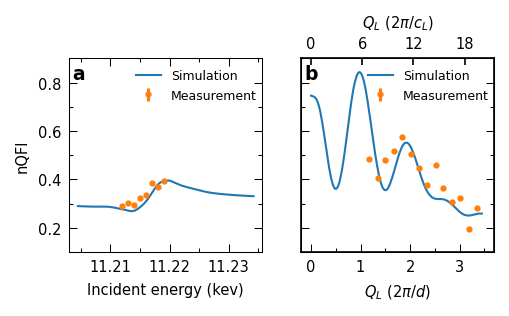

In [8]:
fig, axs = plt.subplots(1,2, dpi=150, sharey=True, figsize=(6.75/2,6.75*2/9),                   gridspec_kw=dict(left=0.12,right=0.96,bottom=0.10,top=0.96,hspace=0.))
axs[0].plot(omega,QFI_E,lw=1,label='Simulation')
axs[0].errorbar(omega_data, QFI_E_data, yerr=QFI_E_err, fmt='o', markersize=2,label='Measurement')
axs[0].legend(fontsize=6, loc=(0.32,0.75), frameon=False)
axs[1].plot(newmomenta,QFI_M,lw=1,label='Simulation')
axs[1].errorbar(newmomenta_data, QFI_M_data, yerr=QFI_M_err, fmt='o', markersize=2,label='Measurement')
axs[1].legend(fontsize=6, loc=(0.32,0.75), frameon=False)
for ax in axs:
    make_theme(ax, ticklength=4)
axs[0].set_ylim(0.1,0.9)
axs[1].set_xlim(-0.2,3.7)
axs[1].set_xticks(np.arange(0,3.1,1))
axs[0].set_xlabel('Incident energy (kev)')
axs[1].set_xlabel('$Q_L$ $(2\pi/d)$')
axs[0].set_ylabel('nQFI')
axs[0].axhline(y = 1, color = 'r', linestyle = '--',lw=0.5)
axs[1].axhline(y = 1, color = 'r', linestyle = '--',lw=0.5)
axs_top = axs[1].twiny()
axs_top.set_xlim(-0.2/Lfactor,3.7/Lfactor)
axs_top.set_xticks(np.arange(0,18.1,6))
axs_top.tick_params(direction='in')
axs_top.set_xlabel('$Q_L$ ($2\pi/c_L$)')
plot_label(axs[0], 'a', x=0.05, y=0.92, color='k')
plot_label(axs[1], 'b', x=0.05, y=0.92, color='k')
plt.show()

# Fig 7

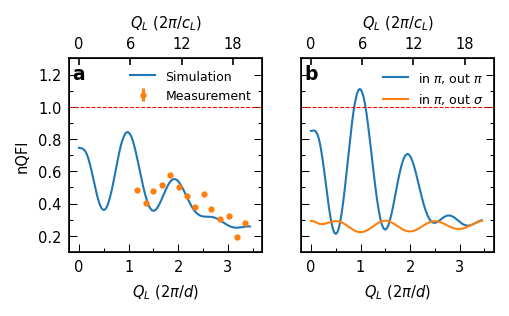

In [9]:
# first run Qmap section of Figure 6
# to get the sum part of Figure 7

d = 2.53614
Lfactor = 0.426991866 * d / (2*np.pi)

# temperature
T=9.
kB=8.6173303e-5
beta = 1 / (kB * T)

f = h5py.File('data/Ce_Qpol_exp.hdf5', 'r')
Ls = np.array(f['pol']['L'])
eloss = np.array(f['pol']['eloss'])
rixs1 = np.array(f['pol']['rixs1'])
rixs2 = np.array(f['pol']['rixs2'])
rixs1_con = np.array(f['pol']['rixs1_con'])
rixs2_con = np.array(f['pol']['rixs2_con'])
denom1 = np.array(f['pol']['denom1'])
denom2 = np.array(f['pol']['denom2'])
f.close()

momenta = Ls*Lfactor

factor = 2 * np.tanh(beta * eloss / 2) * (1-np.exp(-beta * eloss) )

# element-wise multiplication along axis 'eloss'
given_axis = 1
dim = np.ones((1,rixs1.ndim),int).ravel()
dim[given_axis] = -1
factor_reshaped = factor.reshape(dim)
summand1 = rixs1 * factor_reshaped + rixs1_con * factor_reshaped
summand2 = rixs2 * factor_reshaped + rixs2_con * factor_reshaped

# integration over eloss to get nominator
step = eloss[1] - eloss[0]
nominator1 = np.sum(summand1, axis=1)*step
nominator2 = np.sum(summand2, axis=1)*step

# get QFI
QFI1_M = nominator1 / denom1
QFI2_M = nominator2 / denom2

# plotting the result
fig, axs = plt.subplots(1,2, dpi=150, sharey=True, figsize=(6.75/2,6.75*2/9),                   gridspec_kw=dict(left=0.12,right=0.96,bottom=0.10,top=0.96,hspace=0.))
axs[0].plot(newmomenta,QFI_M,lw=1,label='Simulation')
axs[0].errorbar(newmomenta_data, QFI_M_data, yerr=QFI_M_err, fmt='o', markersize=2,label='Measurement')
axs[0].legend(fontsize=6, loc="upper right", frameon=False)
axs[1].plot(momenta,QFI1_M,lw=1,label=r"in $\pi$, out $\pi$")
axs[1].plot(momenta,QFI2_M,lw=1,label=r"in $\pi$, out $\sigma$")
axs[1].legend(fontsize=6, loc="upper right", frameon=False)
for ax in axs:
    make_theme(ax, ticklength=4)
axs[0].set_ylim(0.1,1.3)
axs[0].set_ylabel('nQFI')
for i in range(2):
    axs[i].set_xlim(-0.2,3.7)
    axs[i].set_xticks(np.arange(0,3.1,1))
    axs[i].set_xlabel('$Q_L$ $(2\pi/d)$')
    axs[i].axhline(y = 1, color = 'r', linestyle = '--',lw=0.5)
    axs_top = axs[i].twiny()
    axs_top.set_xlim(-0.2/Lfactor,3.7/Lfactor)
    axs_top.set_xticks(np.arange(0,18.1,6))
    axs_top.tick_params(direction='in')
    axs_top.set_xlabel('$Q_L$ ($2\pi/c_L$)')
plot_label(axs[0], 'a', x=0.05, y=0.92, color='k')
plot_label(axs[1], 'b', x=0.05, y=0.92, color='k')
plt.show()

# Fig 8

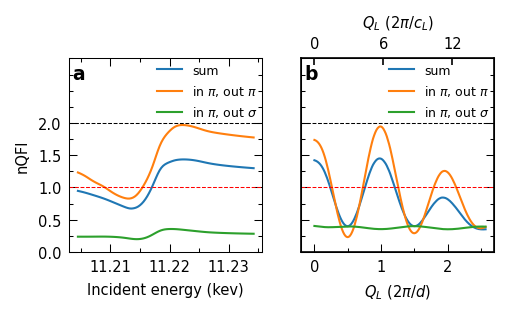

In [10]:
d = 2.53614
factor = 0.426991866 * d / (2*np.pi)

f = h5py.File('data/Ce_Esum.hdf5', 'r')
omega = np.array(f['sum']['omega'])
QFI_E = np.array(f['sum']['QFI'])
f.close()

f = h5py.File('data/Ce_Qsum.hdf5', 'r')
momenta = np.array(f['sum']['momenta'])
QFI_M = np.array(f['sum']['QFI'])
f.close()

f = h5py.File('data/Ce_Epolar.hdf5', 'r')
omega1 = np.array(f['pi_pi']['omega'])
QFI1_E = np.array(f['pi_pi']['QFI'])
omega2 = np.array(f['pi_sigma']['omega'])
QFI2_E = np.array(f['pi_sigma']['QFI'])
f.close()

f = h5py.File('data/Ce_Qpolar.hdf5', 'r')
momenta1 = np.array(f['pi_pi']['momenta'])
QFI1_M = np.array(f['pi_pi']['QFI'])
momenta2 = np.array(f['pi_sigma']['momenta'])
QFI2_M = np.array(f['pi_sigma']['QFI'])
f.close()

fig, axs = plt.subplots(1,2, dpi=150, sharey=True, figsize=(6.75/2,6.75*2/9),
                       gridspec_kw=dict(left=0.12,right=0.96,bottom=0.10,top=0.96,hspace=0.))

axs[0].plot(omega,QFI_E,label=r"sum",lw=1)
axs[0].plot(omega1,QFI1_E,label=r"in $\pi$, out $\pi$",lw=1)
axs[0].plot(omega2,QFI2_E,label=r"in $\pi$, out $\sigma$",lw=1)

axs[1].plot(momenta,QFI_M,label=r"sum",lw=1)
axs[1].plot(momenta1,QFI1_M,label=r"in $\pi$, out $\pi$",lw=1)
axs[1].plot(momenta2,QFI2_M,label=r"in $\pi$, out $\sigma$",lw=1)

axs[0].legend(loc=(0.43,0.66), fontsize=6, frameon=False)
axs[1].legend(loc=(0.43,0.66), fontsize=6, frameon=False)
for ax in axs:
    make_theme(ax, ticklength=4)
axs[0].set_ylim(0,3)
axs[0].set_yticks(np.arange(0,2.1,0.5))
axs[1].set_ylim(0,3)
axs[1].set_xlim(-0.2,2.7)
axs[1].set_xticks(np.arange(0.,2.51,1))
axs[0].set_xlabel('Incident energy (kev)')
axs[1].set_xlabel('$Q_L$ $(2\pi/d)$')
axs[0].set_ylabel('nQFI')
axs_top = axs[1].twiny()
axs_top.set_xlim(-0.2/factor,2.7/factor)
axs_top.set_xticks(np.arange(0,12.1,6))
axs_top.tick_params(direction='in')
axs_top.set_xlabel('$Q_L$ ($2\pi/c_L$)')
axs[0].axhline(y = 1, color = 'r', linestyle = '--',lw=0.5)
axs[1].axhline(y = 1, color = 'r', linestyle = '--',lw=0.5)
axs[0].axhline(y = 2, color = 'k', linestyle = '--',lw=0.5)
axs[1].axhline(y = 2, color = 'k', linestyle = '--',lw=0.5)
plot_label(axs[0], 'a', x=0.05, y=0.92, color='k')
plot_label(axs[1], 'b', x=0.05, y=0.92, color='k')
plt.show()

# Supplementary Figure 1

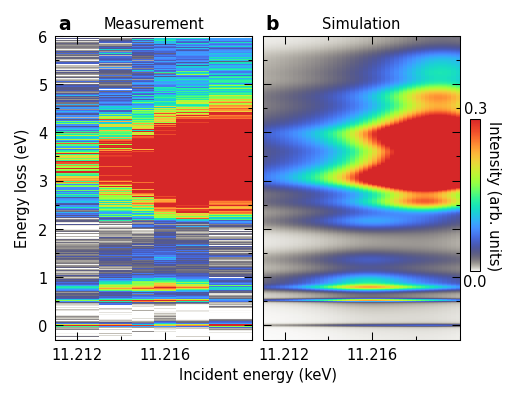

In [11]:
Emap_data = dict(eloss=None, omega=[], intensity=[])

f = h5py.File('data/Ta_data_energyMap.hdf5', 'r')
scan = dict()
for scan_no in f:
    for dset_name in f[scan_no]:
        scan[dset_name] = np.array(f[scan_no][dset_name])
    if Emap_data['eloss'] is None:
        Emap_data['eloss'] = scan['x']
    Emap_data['omega'].append(scan['Ei'])
    bg = np.mean(scan['y'][np.logical_and(scan['x']>=250., scan['x']<=350.)])
    Emap_data['intensity'].append(np.interp(Emap_data['eloss'], scan['x']-scan['xoffset'], (scan['y']-bg)/scan['ab_factor']))
Emap_data['intensity'] = np.vstack(Emap_data['intensity']).T
f.close()

f = h5py.File('data/Ta_calc_energyMap.hdf5', 'r')
Emap_calc = dict()
for dset_name in f['energyMap']:
    Emap_calc[dset_name] = np.array(f['energyMap'][dset_name])
f.close()

fig = plt.figure(figsize=(6.75/2,6.75/2/4*3), dpi=150)
gs1 = fig.add_gridspec(nrows=1, ncols=1, left=0.10, right=0.49, top=0.92, bottom=0.12) # Emap1
gs2 = fig.add_gridspec(nrows=1, ncols=1, left=0.51, right=0.90, top=0.92, bottom=0.12) # Emap2
gs3 = fig.add_gridspec(nrows=1, ncols=1, left=0.92, right=0.94, top=0.70, bottom=0.30) # colorbar
axs  = [fig.add_subplot(gs) for gs in gs1] + [fig.add_subplot(gs) for gs in gs2] # Emaps
axs += [fig.add_subplot(gs) for gs in gs3] # colorbar

## plot
_, art = plot_image(Emap_data['intensity'], x=Emap_data['omega'], y=Emap_data['eloss']/1e3,
                    ax=axs[0], cmap=turbo_w(), vmin=0., vmax=0.3)
_, art = plot_image(Emap_calc['rixs'].T, x=Emap_calc['omega'], y=Emap_calc['eloss'],
                    ax=axs[1], cmap=turbo_w(), vmin=0., vmax=0.3)
## colorbar
cbar = plt.colorbar(art, ax=axs[1], cax=axs[2])
format_cbar(cbar, padding=0.07)
## format
axs[1].set_xlim(axs[0].get_xlim())
for ax in axs[:2]:
    make_theme(ax, ticklength=4)
    ax.set_ylim(-0.3,6)
    ax.set_yticks(np.arange(0.,6.1,1.))
    ax.set_xticks(np.arange(11.212,11.2191,0.004))
axs[1].tick_params(labelleft=False)
axs[0].set_xlabel('Incident energy (keV)')
axs[0].xaxis.set_label_coords(1.028, -.09)
axs[0].set_ylabel('Energy loss (eV)')
plot_label(axs[0], 'a', x=0.05, y=1.04, color='k')
axs[0].text(0.5, 1.04, 'Measurement', color='k', transform=axs[0].transAxes,
            horizontalalignment='center', verticalalignment='center')
plot_label(axs[1], 'b', x=0.05, y=1.04, color='k')
axs[1].text(0.5, 1.04, 'Simulation', color='k', transform=axs[1].transAxes,
            horizontalalignment='center', verticalalignment='center')
plt.show()

# Supplementary Figure 2

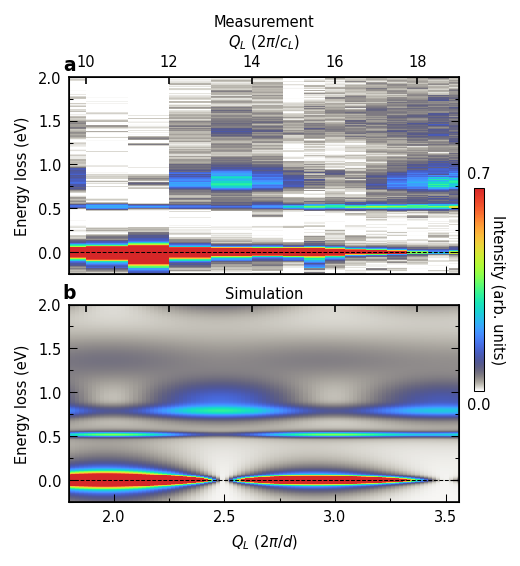

In [12]:
d = 2.7
factor = 0.436029515 * d / (2*np.pi)
Qmap_data = dict(eloss=None, HKL=[], intensity=[])

f = h5py.File('data/Ta_data_qMap.hdf5', 'r')
scan = dict()
for scan_no in f:
    for dset_name in f[scan_no]:
        scan[dset_name] = np.array(f[scan_no][dset_name])
    if Qmap_data['eloss'] is None:
        Qmap_data['eloss'] = scan['x']
    Qmap_data['HKL'].append(scan['HKL'])
    bg = np.mean(scan['y'][np.logical_and(scan['x']>=250., scan['x']<=350.)])
    Qmap_data['intensity'].append(np.interp(Qmap_data['eloss'], scan['x']-scan['xoffset'], (scan['y']-bg)/scan['ab_factor']))
Qmap_data['intensity'] = np.vstack(Qmap_data['intensity']).T
Qmap_data['HKL'] = np.vstack(Qmap_data['HKL'])
f.close()

f = h5py.File('data/Ta_calc_qMap.hdf5', 'r')
Qmap_calc = dict()
for dset_name in f['qMap']:
    Qmap_calc[dset_name] = np.array(f['qMap'][dset_name])
f.close()

fig = plt.figure(figsize=(6.75/2,6.75/2), dpi=150)
gs1 = fig.add_gridspec(nrows=1, ncols=1, left=0.12, right=0.89, top=0.94, bottom=0.55) # Qmap1
gs2 = fig.add_gridspec(nrows=1, ncols=1, left=0.12, right=0.89, top=0.49, bottom=0.10) # Qmap2
gs3 = fig.add_gridspec(nrows=1, ncols=1, left=0.92, right=0.94, top=0.72, bottom=0.32)  # colorbar
axs =  [fig.add_subplot(gs) for gs in gs1] + [fig.add_subplot(gs) for gs in gs2] # Qmaps
axs += [fig.add_subplot(gs) for gs in gs3] # colorbar

_, art = plot_image(Qmap_data['intensity'], x=Qmap_data['HKL'][:,2]*factor, y=Qmap_data['eloss']/1e3,
                    ax=axs[0], cmap=turbo_w(), vmin=0., vmax=0.7)
choose = Qmap_calc['eloss']<=2.1
_, art = plot_image(Qmap_calc['rixs'].T[choose,:], x=Qmap_calc['Ls']*factor, y=Qmap_calc['eloss'][choose],
                    ax=axs[1], cmap=turbo_w(), vmin=0., vmax=0.7)
## colorbar
cbar = plt.colorbar(art, ax=axs[1], cax=axs[2])
format_cbar(cbar, padding=0.07)
## format
for ax in axs[:2]:
    make_theme(ax, ticklength=4)
    ax.axhline(y=0., ls='--', lw=0.5, color='k', zorder=100)
    ax.set_ylim(-0.25,2)
    ax.set_yticks(np.arange(0.,2.1,0.5))
    ax.set_xlim(9.6*factor,19*factor)
    ax.set_xticks(np.arange(2,4,0.5))
    ax.set_ylabel('Energy loss (eV)')
axs[0].tick_params(labelbottom=False)
axs[1].set_xlabel('$Q_L$ ($2\pi/d$)')
plot_label(axs[0], 'a', x=0.0, y=1.06, color='k')
axs[0].set_title('Measurement', fontsize=7, pad=3)
plot_label(axs[1], 'b', x=0.0, y=1.06, color='k')
axs[1].set_title('Simulation', fontsize=7, pad=3)
axs_top = axs[0].twiny()
axs_top.set_xlim(9.6,19)
axs_top.set_xlabel('$Q_L$ ($2\pi/c_L$)')
axs_top.tick_params(direction='in')
axs_top = axs[1].twiny()
axs_top.set_xlim(9.6,19)
axs_top.tick_params(direction='in',labeltop=False)

plt.show()

# Supplementary Figure 3

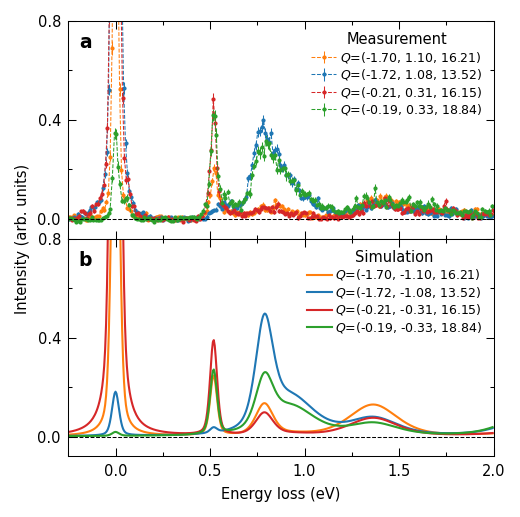

In [13]:
Cmap_data = []
f = h5py.File('data/Ta_data_cutMap.hdf5', 'r')
scan = dict()
for scan_no, color in zip(f, ['C1','C0','C3','C2']):
    for dset_name in f[scan_no]:
        scan[dset_name] = np.array(f[scan_no][dset_name])
    bg = np.mean(scan['y'][np.logical_and(scan['x']>=250., scan['x']<=350.)])
    Cmap_data.append(dict(x=(scan['x']-scan['xoffset'])/1e3, y=(scan['y']-bg)/scan['ab_factor'], 
                          yerr=scan['yerr']/scan['ab_factor'], HKLc=[scan['HKL'][0], scan['HKL'][1], scan['HKL'][2], scan['qc']]))
f.close()

f = h5py.File('data/Ta_calc_cutMap.hdf5', 'r')
for calc_no, color in zip(f, ['C1','C0','C3','C2']):
    loss = np.array(f[calc_no]['eloss'])
    rixs = np.array(f[calc_no]['rixs'])
    HKL  = np.array(f[calc_no]['HKL'])
    ax.plot(loss, rixs, '-', lw=1, color=color,
            label='$Q$=({:.2f}, {:.2f}, {:.2f})'.format(HKL[0], 0, HKL[2]))
Cmap_calc = []
Cmap_calc.append(dict(x=np.array(f['0']['eloss']), y=np.array(f['0']['rixs']), Q='(-1.70, -1.10, 16.21)', qc=6))
Cmap_calc.append(dict(x=np.array(f['1']['eloss']), y=np.array(f['1']['rixs']), Q='(-1.72, -1.08, 13.52)', qc=5))
Cmap_calc.append(dict(x=np.array(f['2']['eloss']), y=np.array(f['2']['rixs']), Q='(-0.21, -0.31, 16.15)', qc=6))
Cmap_calc.append(dict(x=np.array(f['3']['eloss']), y=np.array(f['3']['rixs']), Q='(-0.19, -0.33, 18.84)', qc=5))
f.close()

fig, axs = plt.subplots(2, 1, sharex=True, sharey=True, figsize=(6.75/2,6.75/2), dpi=150,
                        gridspec_kw=dict(left=0.12, right=0.96, bottom=0.10, top=0.96, hspace=0.))

## plot
for scan1, scan2, color in zip(Cmap_data, Cmap_calc, ['C1','C0','C3','C2']):
    choose = scan1['x']<=2.
    axs[0].errorbar(scan1['x'][choose], scan1['y'][choose], scan1['yerr'][choose], fmt='o', color=color, ls='--', lw=0.5, ms=1,
                    label='$Q$=({:.2f}, {:.2f}, {:.2f})'.format(scan1['HKLc'][0], abs(scan1['HKLc'][1]), scan1['HKLc'][2]))
    choose = scan2['x']<=2.
    axs[1].plot(scan2['x'][choose], scan2['y'][choose], '-', lw=1, color=color, label='$Q$='+scan2['Q'])
## format
axs[0].legend(loc='upper right', frameon=False, handletextpad=0.3, labelspacing=0.2, fontsize=6, title='Measurement')
axs[1].legend(loc='upper right', frameon=False, handletextpad=0.3, labelspacing=0.2, fontsize=6, title='Simulation')
for ax in axs:
    make_theme(ax, ticklength=4)
    ax.axhline(y=0., ls='--', lw=0.5, color='k', zorder=100)
axs[0].set_xlim(-0.25, 2.)
axs[0].set_xticks(np.arange(0.,2.01,0.5))
axs[0].set_ylim(-0.08,0.6)
axs[0].set_yticks(np.arange(0.,1.01,0.4))
axs[1].set_xlabel('Energy loss (eV)')
axs[0].set_ylabel('Intensity (arb. units)')
axs[0].yaxis.set_label_coords(-0.09,0.)
plot_label(axs[0], 'a', x=0.04, y=0.9, color='k')
plot_label(axs[1], 'b', x=0.04, y=0.9, color='k')
plt.show()

# Supplementary Figure 4

## Emap

In [14]:
# temperature
T=9.
kB=8.6173303e-5
beta = 1 / (kB * T)

# get simulation data
f = h5py.File('data/Ta_Esum_exp.hdf5', 'r')
omega = np.array(f['sum']['omega'])
eloss = np.array(f['sum']['eloss'])
rixs = np.array(f['sum']['rixs'])
rixs_con = np.array(f['sum']['rixs_con'])
denom = np.array(f['sum']['denom'])
f.close()

factor = 2 * np.tanh(beta * eloss / 2) * (1-np.exp(-beta * eloss) )

# element-wise multiplication along axis 'eloss'
given_axis = 1
dim = np.ones((1,rixs.ndim),int).ravel()
dim[given_axis] = -1
factor_reshaped = factor.reshape(dim)
summand_pos = rixs * factor_reshaped
summand_con = rixs_con * factor_reshaped

# integration over eloss to get nominator
step = eloss[1] - eloss[0]
nominator_pos = np.sum(summand_pos, axis=1)*step
nominator_con = np.sum(summand_con, axis=1)*step
nominator = nominator_pos + nominator_con

# get QFI
QFI_E_pos = nominator_pos / denom
QFI_E_con = nominator_con / denom
QFI_E = QFI_E_pos + QFI_E_con

# get experimental data
eloss_data=eloss[0:1201]

Emap_data = dict(eloss=eloss_data, omega=[], intensity=[])
f = h5py.File('data/Ta_data_energyMap.hdf5', 'r')
scan = dict()
for scan_no in f:
    for dset_name in f[scan_no]:
        scan[dset_name] = np.array(f[scan_no][dset_name])
    Emap_data['omega'].append(scan['Ei'])
    bg = np.mean(scan['y'][np.logical_and(scan['x']>=250., scan['x']<=350.)])
    Emap_data['intensity'].append(np.interp(Emap_data['eloss'], (scan['x']-scan['xoffset'])/1e3, (scan['y']-bg)/scan['ab_factor']))
f.close()

omega_data = np.array(Emap_data['omega'])
rixs_data=np.array(Emap_data['intensity'])

factor_data = 2 * np.tanh(beta * eloss_data / 2) * (1-np.exp(-beta * eloss_data) )

# element-wise multiplication along axis 'eloss'
given_axis = 1
dim_data = np.ones((1,rixs_data.ndim),int).ravel()
dim_data[given_axis] = -1
factor_reshaped_data = factor_data.reshape(dim_data)
summand_data = rixs_data * factor_reshaped_data

# integration over eloss to get nominator
step_data = eloss_data[1] - eloss_data[0]
nominator_pos_data = np.sum(summand_data, axis=1)*step_data

choose = [25, 32, 35, 38, 42, 49]
nominator_con_data = nominator_con[choose]
denom_data = denom[choose]

# get QFI
QFI_E_pos_data = nominator_pos_data / denom_data
QFI_E_con_data = nominator_con_data / denom_data 
QFI_E_data = QFI_E_pos_data + QFI_E_con_data

# experimental error bar
Emap_data = dict(eloss=[], yerr=[])
scan = dict()
f = h5py.File('data/Ta_data_energyMap.hdf5', 'r')
for scan_no in f:
    for dset_name in f[scan_no]:
        scan[dset_name] = np.array(f[scan_no][dset_name])
    eloss = np.array((scan['x']-scan['xoffset'])/1e3)
    choose = eloss>0
    Emap_data['eloss'].append(eloss[choose])
    yerr = np.array(scan['yerr']/scan['ab_factor'])
    Emap_data['yerr'].append(yerr[choose])

nominator_err = []

for i in range(len(Emap_data['eloss'])):
    eloss_data = np.array(Emap_data['eloss'][i])
    factor_data = 2 * np.tanh(beta * eloss_data / 2) * (1-np.exp(-beta * eloss_data) )
    step_data = np.round(eloss_data[1]-eloss_data[0],2)
    err_data = Emap_data['yerr'][i]
    err_data = err_data * factor_data * step_data
    err = np.sqrt(np.sum(err_data ** 2))
    nominator_err.append(err)

nominator_err = np.array(nominator_err)
QFI_E_err = nominator_err / denom_data

## Qmap

In [15]:
d = 2.7
Lfactor = 0.436029515 * d / (2*np.pi)

# temperature
T=9.
kB=8.6173303e-5
beta = 1 / (kB * T)

# get simulation data
f = h5py.File('data/Ta_Qsum_exp.hdf5', 'r')
Ls = np.array(f['sum']['L'])
eloss = np.array(f['sum']['eloss'])
rixs = np.array(f['sum']['rixs'])
rixs_con = np.array(f['sum']['rixs_con'])
denom = np.array(f['sum']['denom'])
f.close()

newmomenta = Ls * Lfactor
factor = 2 * np.tanh(beta * eloss / 2) * (1-np.exp(-beta * eloss) )

# element-wise multiplication along axis 'eloss'
given_axis = 1
dim = np.ones((1,rixs.ndim),int).ravel()
dim[given_axis] = -1
factor_reshaped = factor.reshape(dim)
summand_pos = rixs * factor_reshaped
summand_con = rixs_con * factor_reshaped

# integration over eloss to get nominator
step = eloss[1] - eloss[0]
nominator_pos = np.sum(summand_pos, axis=1)*step
nominator_con = np.sum(summand_con, axis=1)*step

# get QFI
QFI_M_pos = nominator_pos / denom
QFI_M_con = nominator_con / denom
QFI_M = QFI_M_pos + QFI_M_con

# get experimental data
eloss_data=eloss[0:1201]
Mmap_data = dict(eloss=eloss_data, L=[], intensity=[])

f = h5py.File('data/Ta_data_qMap.hdf5', 'r')
scan = dict()
for scan_no in f:
    if (scan_no=='00') | (scan_no=='15'):
        continue
    for dset_name in f[scan_no]:
        scan[dset_name] = np.array(f[scan_no][dset_name])
    Mmap_data['L'].append(round(scan['HKL'][2],1)*Lfactor)
    bg = np.mean(scan['y'][np.logical_and(scan['x']>=250., scan['x']<=350.)])
    Mmap_data['intensity'].append(np.interp(Mmap_data['eloss'], (scan['x']-scan['xoffset'])/1000, (scan['y']-bg)/scan['ab_factor']))
f.close()

newmomenta_data = np.array(Mmap_data['L'])
rixs_data=np.array(Mmap_data['intensity'])

factor_data = 2 * np.tanh(beta * eloss_data / 2) * (1-np.exp(-beta * eloss_data) )

# element-wise multiplication along axis 'eloss'
given_axis = 1
dim_data = np.ones((1,rixs_data.ndim),int).ravel()
dim_data[given_axis] = -1
factor_reshaped_data = factor_data.reshape(dim_data)
summand_data = rixs_data * factor_reshaped_data

# integration over eloss to get nominator
step_data = eloss_data[1] - eloss_data[0]
nominator_pos_data = np.sum(summand_data, axis=1)*step_data

choose = np.array([9, 19, 29, 39, 49, 54, 59, 64, 69, 74, 79, 84, 89, 94])+96
nominator_con_data = nominator_con[choose]

# get denominator
denom_data = denom[choose]

# get QFI
QFI_M_pos_data = nominator_pos_data / denom_data
QFI_M_con_data = nominator_con_data / denom_data
QFI_M_data = QFI_M_pos_data + QFI_M_con_data

# experimental error bar
Mmap_data = dict(eloss=[], yerr=[])
scan = dict()
f = h5py.File('data/Ta_data_qMap.hdf5', 'r')
for scan_no in f:
    if (scan_no=='00') | (scan_no=='15'):
        continue
    for dset_name in f[scan_no]:
        scan[dset_name] = np.array(f[scan_no][dset_name])
    eloss = np.array((scan['x']-scan['xoffset'])/1000)
    choose = eloss>0
    Mmap_data['eloss'].append(eloss[choose])
    bg = np.mean(scan['y'][np.logical_and(scan['x']>=250., scan['x']<=350.)])
    yerr = np.array(scan['yerr']/scan['ab_factor'])
    Mmap_data['yerr'].append(yerr[choose])

nominator_err = []

for i in range(len(Mmap_data['eloss'])):
    eloss_data = np.array(Mmap_data['eloss'][i])
    factor_data = 2 * np.tanh(beta * eloss_data / 2) * (1-np.exp(-beta * eloss_data) )
    step_data = np.round(eloss_data[1]-eloss_data[0],2)
    err_data = Mmap_data['yerr'][i]
    err_data = err_data * factor_data * step_data
    err = np.sqrt(np.sum(err_data ** 2))
    nominator_err.append(err)

nominator_err = np.array(nominator_err)
QFI_M_err = nominator_err / denom_data

## Plotting the result

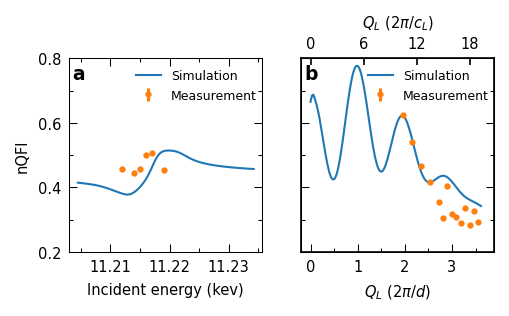

In [16]:
fig, axs = plt.subplots(1,2, dpi=150, sharey=True, figsize=(6.75/2,6.75*2/9),                   gridspec_kw=dict(left=0.12,right=0.96,bottom=0.10,top=0.96,hspace=0.))
axs[0].plot(omega,QFI_E,lw=1,label='Simulation')
axs[0].errorbar(omega_data, QFI_E_data, yerr=QFI_E_err, fmt='o', markersize=2,label='Measurement')
axs[0].legend(fontsize=6, loc=(0.32,0.75), frameon=False)
axs[1].plot(newmomenta,QFI_M,lw=1,label='Simulation')
axs[1].errorbar(newmomenta_data, QFI_M_data, yerr=QFI_M_err, fmt='o', markersize=2,label='Measurement')
axs[1].legend(fontsize=6, loc=(0.32,0.75), frameon=False)
for ax in axs:
    make_theme(ax, ticklength=4)
axs[0].set_ylim(0.2,0.8)
axs[1].set_xlim(-0.2,3.9)
axs[1].set_xticks(np.arange(0,3.1,1))
axs[0].set_xlabel('Incident energy (kev)')
axs[1].set_xlabel('$Q_L$ $(2\pi/d)$')
axs[0].set_ylabel('nQFI')
axs[0].axhline(y = 1, color = 'r', linestyle = '--',lw=0.5)
axs[1].axhline(y = 1, color = 'r', linestyle = '--',lw=0.5)
axs_top = axs[1].twiny()
axs_top.set_xlim(-0.2/Lfactor,3.9/Lfactor)
axs_top.set_xticks(np.arange(0,18.1,6))
axs_top.tick_params(direction='in')
axs_top.set_xlabel('$Q_L$ ($2\pi/c_L$)')
plot_label(axs[0], 'a', x=0.05, y=0.92, color='k')
plot_label(axs[1], 'b', x=0.05, y=0.92, color='k')
plt.show()

# Supplementary Figure 5

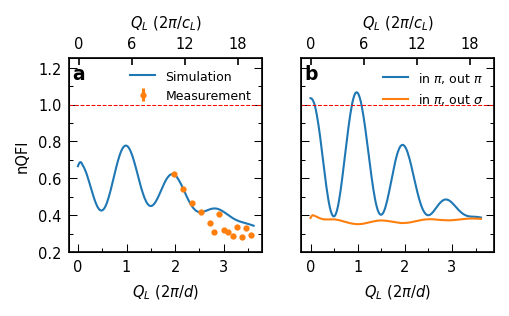

In [17]:
# first run Qmap section of Supplementary Figure 4
# to get the sum part of Supplementary Figure 5

d = 2.7
Lfactor = 0.436029515 * d / (2*np.pi)

# temperature
T=9.
kB=8.6173303e-5
beta = 1 / (kB * T)

f = h5py.File('data/Ta_Qpol_exp.hdf5', 'r')
Ls = np.array(f['pol']['L'])
eloss = np.array(f['pol']['eloss'])
rixs1 = np.array(f['pol']['rixs1'])
rixs2 = np.array(f['pol']['rixs2'])
rixs1_con = np.array(f['pol']['rixs1_con'])
rixs2_con = np.array(f['pol']['rixs2_con'])
denom1 = np.array(f['pol']['denom1'])
denom2 = np.array(f['pol']['denom2'])
f.close()

momenta = Ls*Lfactor

factor = 2 * np.tanh(beta * eloss / 2) * (1-np.exp(-beta * eloss) )

# element-wise multiplication along axis 'eloss'
given_axis = 1
dim = np.ones((1,rixs1.ndim),int).ravel()
dim[given_axis] = -1
factor_reshaped = factor.reshape(dim)
summand1 = rixs1 * factor_reshaped + rixs1_con * factor_reshaped
summand2 = rixs2 * factor_reshaped + rixs2_con * factor_reshaped

# integration over eloss to get nominator
step = eloss[1] - eloss[0]
nominator1 = np.sum(summand1, axis=1)*step
nominator2 = np.sum(summand2, axis=1)*step

# get QFI
QFI1_M = nominator1 / denom1
QFI2_M = nominator2 / denom2

# plotting the result
fig, axs = plt.subplots(1,2, dpi=150, sharey=True, figsize=(6.75/2,6.75*2/9),                   gridspec_kw=dict(left=0.12,right=0.96,bottom=0.10,top=0.96,hspace=0.))
axs[0].plot(newmomenta,QFI_M,lw=1,label='Simulation')
axs[0].errorbar(newmomenta_data, QFI_M_data, yerr=QFI_M_err, fmt='o', markersize=2,label='Measurement')
axs[0].legend(fontsize=6, loc="upper right", frameon=False)
axs[1].plot(momenta,QFI1_M,lw=1,label='in $\pi$, out $\pi$')
axs[1].plot(momenta,QFI2_M,lw=1,label='in $\pi$, out $\sigma$')
axs[1].legend(fontsize=6, loc="upper right", frameon=False)
for ax in axs:
    make_theme(ax, ticklength=4)
axs[0].set_ylim(0.2,1.25)
axs[0].set_yticks(np.arange(0.2,1.21,0.2))
axs[0].set_ylabel('nQFI')
for i in range(2):
    axs[1].set_xlim(-0.2,3.9)
    axs[1].set_xticks(np.arange(0,3.1,1))
    axs[i].set_xlabel('$Q_L$ $(2\pi/d)$')
    axs[i].axhline(y = 1, color = 'r', linestyle = '--',lw=0.5)
    axs_top = axs[i].twiny()
    axs_top.set_xlim(-0.2/Lfactor,3.9/Lfactor)
    axs_top.set_xticks(np.arange(0,18.1,6))
    axs_top.tick_params(direction='in')
    axs_top.set_xlabel('$Q_L$ ($2\pi/c_L$)')
plot_label(axs[0], 'a', x=0.05, y=0.92, color='k')
plot_label(axs[1], 'b', x=0.05, y=0.92, color='k')
plt.show()

# Supplementary Figure 6

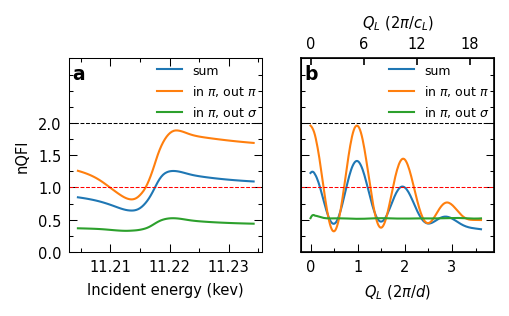

In [18]:
d = 2.7
factor = 0.436029515 * d / (2*np.pi)

f = h5py.File('data/Ta_Esum.hdf5', 'r')
omega = np.array(f['sum']['omega'])
QFI_E = np.array(f['sum']['QFI'])
f.close()

f = h5py.File('data/Ta_Qsum.hdf5', 'r')
momenta = np.array(f['sum']['momenta'])
QFI_M = np.array(f['sum']['QFI'])
f.close()

f = h5py.File('data/Ta_Epolar.hdf5', 'r')
omega1 = np.array(f['pi_pi']['omega'])
QFI1_E = np.array(f['pi_pi']['QFI'])
omega2 = np.array(f['pi_sigma']['omega'])
QFI2_E = np.array(f['pi_sigma']['QFI'])
f.close()

f = h5py.File('data/Ta_Qpolar.hdf5', 'r')
momenta1 = np.array(f['pi_pi']['momenta'])
QFI1_M = np.array(f['pi_pi']['QFI'])
momenta2 = np.array(f['pi_sigma']['momenta'])
QFI2_M = np.array(f['pi_sigma']['QFI'])
f.close()

fig, axs = plt.subplots(1,2, dpi=150, sharey=True, figsize=(6.75/2,6.75*2/9),
                       gridspec_kw=dict(left=0.12,right=0.96,bottom=0.10,top=0.96,hspace=0.))

axs[0].plot(omega,QFI_E,label=r"sum",lw=1)
axs[0].plot(omega1,QFI1_E,label=r"in $\pi$, out $\pi$",lw=1)
axs[0].plot(omega2,QFI2_E,label=r"in $\pi$, out $\sigma$",lw=1)

axs[1].plot(momenta,QFI_M,label=r"sum",lw=1)
axs[1].plot(momenta1,QFI1_M,label=r"in $\pi$, out $\pi$",lw=1)
axs[1].plot(momenta2,QFI2_M,label=r"in $\pi$, out $\sigma$",lw=1)

axs[0].legend(loc=(0.43,0.66), fontsize=6, frameon=False)
axs[1].legend(loc=(0.43,0.66), fontsize=6, frameon=False)
for ax in axs:
    make_theme(ax, ticklength=4)
axs[0].set_ylim(0,3)
axs[0].set_yticks(np.arange(0,2.1,0.5))
axs[1].set_xlim(-0.2,3.9)
axs[1].set_xticks(np.arange(0,3.1,1))
axs[0].set_xlabel('Incident energy (kev)')
axs[1].set_xlabel('$Q_L$ $(2\pi/d)$')
axs[0].set_ylabel('nQFI')
axs_top = axs[1].twiny()
axs_top.set_xlim(-0.2/factor,3.9/factor)
axs_top.tick_params(direction='in')
axs_top.set_xticks(np.arange(0,18.1,6))
axs_top.set_xlabel('$Q_L$ ($2\pi/c_L$)')
axs[0].axhline(y = 1, color = 'r', linestyle = '--',lw=0.5)
axs[1].axhline(y = 1, color = 'r', linestyle = '--',lw=0.5)
axs[0].axhline(y = 2, color = 'k', linestyle = '--',lw=0.5)
axs[1].axhline(y = 2, color = 'k', linestyle = '--',lw=0.5)
plot_label(axs[0], 'a', x=0.05, y=0.92, color='k')
plot_label(axs[1], 'b', x=0.05, y=0.92, color='k')
plt.show()